In [13]:
import numpy as np

In [19]:
import sys
#import numpy
#import pandas
import pandas as pd
import sklearn

print("Python:", sys.executable)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)


Python: C:\Users\Hasti\anaconda3\envs\credit_ml\python.exe
NumPy: 2.5.2
Pandas: 3.0.5
Scikit-learn: 1.9.0


In [21]:
import pandas as pd

df = pd.read_excel(
    "AI-Based_Credit_Bureau_Complaint_Classification_System_2161_VOCs_Quality_Corrected.xlsx"
)

print("Rows:", len(df))
print("Columns:")
print(df.columns.tolist())

Rows: 2161
Columns:
['Complaint_ID', 'Complaint_Date', 'Complaint_Text', 'Complaint_Type', 'Issue_Category', 'Product_Type', 'Lending_Institution', 'Complaint_Source', 'Complaint_Status', 'Resolution_Team', 'Resolution_Time_Days']


In [22]:
# Basic information about the dataset

print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Records:")
display(df.head())


Dataset Shape: (2161, 11)

Data Types:
Complaint_ID                       str
Complaint_Date          datetime64[us]
Complaint_Text                     str
Complaint_Type                     str
Issue_Category                     str
Product_Type                       str
Lending_Institution                str
Complaint_Source                   str
Complaint_Status                   str
Resolution_Team                    str
Resolution_Time_Days             int64
dtype: object

First 5 Records:


,Complaint_ID,Complaint_Date,Complaint_Text,Complaint_Type,Issue_Category,Product_Type,Lending_Institution,Complaint_Source,Complaint_Status,Resolution_Team,Resolution_Time_Days
0,VOC0001,2026-02-03,"My personal loan was closed three months ago, ...",Closed Loan Still Active,Account Information,Personal Loan,HDFC Bank,Email,Open,Escalation Team,2
1,VOC0002,2026-07-11,Mera loan close ho gaya hai lekin CIBIL report...,Closed Loan Still Active,Account Information,Home Loan,SBI,Customer Portal,In Progress,Escalation Team,3
2,VOC0003,2026-01-30,This credit card does not belong to me. Fraudl...,Unauthorized Credit Card,Account Ownership,Credit Card,ICICI Bank,Customer Care,Resolved,Escalation Team,8
3,VOC0004,2026-05-27,माझ्या अहवालात DPD चुकीचा दाखवत आहे. मी सर्व E...,Days Past Due (DPD) Incorrect,Account Information,Auto Loan,Kotak Mahindra Bank,Mobile App,Closed,Escalation Team,12
4,VOC0005,2026-02-27,My credit score has dropped by almost 80 point...,Unexpected Credit Score Drop,Credit Score,Personal Loan,Axis Bank,Email,Open,Escalation Team,2


In [23]:
print("Number of Issue Categories:",
      df["Issue_Category"].nunique())

print("\nIssue Category Distribution:")
print(df["Issue_Category"].value_counts())

Number of Issue Categories: 8

Issue Category Distribution:
Issue_Category
Account Information     588
Personal Information    401
Enquiry Ownership       297
Account Ownership       277
Credit Score            222
Login Issue             161
Contact Bank            138
Credit Report            77
Name: count, dtype: int64


In [27]:
print("\nExact Issue Category Names:")
for category in df["Issue_Category"].unique():
    print("-", category)


Exact Issue Category Names:
- Account Information
- Account Ownership
- Credit Score
- Personal Information
- Enquiry Ownership
- Login Issue
- Credit Report
- Contact Bank


In [29]:
print("Missing values:\n")
print(df.isnull().sum())

Missing values:

Complaint_ID            0
Complaint_Date          0
Complaint_Text          0
Complaint_Type          0
Issue_Category          0
Product_Type            0
Lending_Institution     0
Complaint_Source        0
Complaint_Status        0
Resolution_Team         0
Resolution_Time_Days    0
dtype: int64


In [31]:
print("Duplicate complete rows:",
      df.duplicated().sum())

print("Duplicate Complaint IDs:",
      df["Complaint_ID"].duplicated().sum())

print("Duplicate Complaint Text:",
      df["Complaint_Text"].duplicated().sum())

Duplicate complete rows: 0
Duplicate Complaint IDs: 0
Duplicate Complaint Text: 0


In [33]:
for category in df["Issue_Category"].unique():

    print("\n" + "=" * 80)
    print("ISSUE CATEGORY:", category)
    print("=" * 80)

    samples = df[df["Issue_Category"] == category]["Complaint_Text"].head(5)

    for i, text in enumerate(samples, 1):
        print(f"{i}. {text}")


ISSUE CATEGORY: Account Information
1. My personal loan was closed three months ago, but it is still showing as active in my credit report.
2. Mera loan close ho gaya hai lekin CIBIL report mein abhi bhi active show ho raha hai. Is wajah se mera naya loan reject ho gaya.
3. माझ्या अहवालात DPD चुकीचा दाखवत आहे. मी सर्व EMI वेळेवर भरले आहेत. कृपया दुरुस्ती करा.
4. Dear Nodal Officer, As check my report I am seeing that my HDFC credit card is showing Overdue Amount and also DPD's as I have paid every Emi on time. Kindly correct it asap.
5. I have fully paid my personal but it is showing as Settled in report. Kindly remove that settlement status from my loan. I have attached NOC for reference.

ISSUE CATEGORY: Account Ownership
1. This credit card does not belong to me. Fraudlent loan is showing in my latest report
2. Fraudulent loan is showing in my latest report. Maine ye loan kabhi nahi liya hai, please investigate immediately.
3. This credit card does not belong to me. I have never ap

In [35]:
ml_df = df[["Complaint_Text", "Issue_Category"]].copy()

print("ML Dataset Shape:", ml_df.shape)
display(ml_df.head())

ML Dataset Shape: (2161, 2)


,Complaint_Text,Issue_Category
0,"My personal loan was closed three months ago, ...",Account Information
1,Mera loan close ho gaya hai lekin CIBIL report...,Account Information
2,This credit card does not belong to me. Fraudl...,Account Ownership
3,माझ्या अहवालात DPD चुकीचा दाखवत आहे. मी सर्व E...,Account Information
4,My credit score has dropped by almost 80 point...,Credit Score


In [37]:
print("Missing Complaint_Text:",
      ml_df["Complaint_Text"].isnull().sum())

print("Missing Issue_Category:",
      ml_df["Issue_Category"].isnull().sum())

Missing Complaint_Text: 0
Missing Issue_Category: 0


In [41]:
import re

def clean_text(text):
    text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Replace multiple spaces/newlines with one space
    text = re.sub(r"\s+", " ", text)
    
    # Remove leading/trailing spaces
    text = text.strip()
    
    return text

ml_df["Clean_Complaint_Text"] = ml_df["Complaint_Text"].apply(clean_text)

display(
    ml_df[["Complaint_Text", "Clean_Complaint_Text"]].head(10)
)

,Complaint_Text,Clean_Complaint_Text
0,"My personal loan was closed three months ago, ...","my personal loan was closed three months ago, ..."
1,Mera loan close ho gaya hai lekin CIBIL report...,mera loan close ho gaya hai lekin cibil report...
2,This credit card does not belong to me. Fraudl...,this credit card does not belong to me. fraudl...
3,माझ्या अहवालात DPD चुकीचा दाखवत आहे. मी सर्व E...,माझ्या अहवालात dpd चुकीचा दाखवत आहे. मी सर्व e...
4,My credit score has dropped by almost 80 point...,my credit score has dropped by almost 80 point...
5,I am writing to formally log a critical discre...,i am writing to formally log a critical discre...
6,maine kabhi bhi ye credit institutionse koi bh...,maine kabhi bhi ye credit institutionse koi bh...
7,I am Krishna Kishore as check the latest repor...,i am krishna kishore as check the latest repor...
8,"Dear Nodal Officer, As check my report I am se...","dear nodal officer, as check my report i am se..."
9,I have fully paid my personal but it is showin...,i have fully paid my personal but it is showin...


In [43]:
duplicate_texts = ml_df[
    ml_df["Clean_Complaint_Text"].duplicated(keep=False)
].sort_values("Clean_Complaint_Text")

print("Rows involved in duplicate complaint text:",
      len(duplicate_texts))

display(duplicate_texts.head(20))

Rows involved in duplicate complaint text: 0


,Complaint_Text,Issue_Category,Clean_Complaint_Text


In [45]:
label_conflicts = (
    ml_df.groupby("Clean_Complaint_Text")["Issue_Category"]
    .nunique()
    .reset_index(name="Number_of_Categories")
)

label_conflicts = label_conflicts[
    label_conflicts["Number_of_Categories"] > 1
]

print("Complaint texts assigned to multiple Issue Categories:",
      len(label_conflicts))

display(label_conflicts.head(20))

Complaint texts assigned to multiple Issue Categories: 0


,Clean_Complaint_Text,Number_of_Categories


In [47]:
category_counts = (
    ml_df["Issue_Category"]
    .value_counts()
    .sort_values(ascending=False)
)

display(category_counts)

Issue_Category
Account Information     588
Personal Information    401
Enquiry Ownership       297
Account Ownership       277
Credit Score            222
Login Issue             161
Contact Bank            138
Credit Report            77
Name: count, dtype: int64

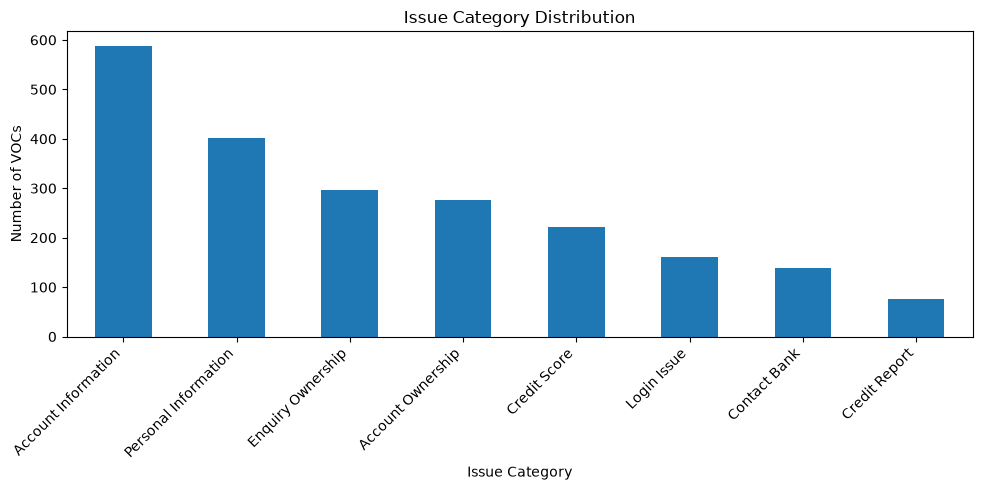

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

category_counts.plot(kind="bar")

plt.title("Issue Category Distribution")
plt.xlabel("Issue Category")
plt.ylabel("Number of VOCs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [51]:
X = ml_df["Clean_Complaint_Text"]

y = ml_df["Issue_Category"]

print("Features:", X.shape)
print("Target:", y.shape)

print("\nNumber of classes:", y.nunique())
print("\nClasses:")
print(y.unique())

Features: (2161,)
Target: (2161,)

Number of classes: 8

Classes:
<StringArray>
[ 'Account Information',    'Account Ownership',         'Credit Score',
 'Personal Information',    'Enquiry Ownership',          'Login Issue',
        'Credit Report',         'Contact Bank']
Length: 8, dtype: str


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



In [55]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 1728
Testing samples: 433

Training class distribution:
Issue_Category
Account Information     470
Personal Information    321
Enquiry Ownership       237
Account Ownership       221
Credit Score            178
Login Issue             129
Contact Bank            110
Credit Report            62
Name: count, dtype: int64

Testing class distribution:
Issue_Category
Account Information     118
Personal Information     80
Enquiry Ownership        60
Account Ownership        56
Credit Score             44
Login Issue              32
Contact Bank             28
Credit Report            15
Name: count, dtype: int64


In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Word-level TF-IDF
word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    sublinear_tf=True
)

# Character-level TF-IDF
char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=50000,
    sublinear_tf=True
)

In [63]:
X_train_word = word_tfidf.fit_transform(X_train)
X_test_word = word_tfidf.transform(X_test)

X_train_char = char_tfidf.fit_transform(X_train)
X_test_char = char_tfidf.transform(X_test)


In [64]:
print("Word TF-IDF training shape:", X_train_word.shape)
print("Word TF-IDF testing shape:", X_test_word.shape)

print("Character TF-IDF training shape:", X_train_char.shape)
print("Character TF-IDF testing shape:", X_test_char.shape)

Word TF-IDF training shape: (1728, 5296)
Word TF-IDF testing shape: (433, 5296)
Character TF-IDF training shape: (1728, 9466)
Character TF-IDF testing shape: (433, 9466)


In [67]:
from scipy.sparse import hstack

X_train_tfidf = hstack([
    X_train_word,
    X_train_char
])

X_test_tfidf = hstack([
    X_test_word,
    X_test_char
])

print("Final training feature matrix:",
      X_train_tfidf.shape)

print("Final testing feature matrix:",
      X_test_tfidf.shape)

Final training feature matrix: (1728, 14762)
Final testing feature matrix: (433, 14762)


In [74]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Label Mapping:")

for number, category in enumerate(label_encoder.classes_):
    print(number, "→", category)

Label Mapping:
0 → Account Information
1 → Account Ownership
2 → Contact Bank
3 → Credit Report
4 → Credit Score
5 → Enquiry Ownership
6 → Login Issue
7 → Personal Information


In [76]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    C=2.0,
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs"
)

logistic_model.fit(
    X_train_tfidf,
    y_train_encoded
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [78]:
y_pred_lr = logistic_model.predict(X_test_tfidf)

print("Predictions generated:", len(y_pred_lr))

Predictions generated: 433


In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

accuracy_lr = accuracy_score(
    y_test_encoded,
    y_pred_lr
)

precision_lr, recall_lr, f1_lr, _ = precision_recall_fscore_support(
    y_test_encoded,
    y_pred_lr,
    average="macro",
    zero_division=0
)


In [82]:

print("Logistic Regression Results")
print("=" * 50)

print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"Macro F1 : {f1_lr:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred_lr,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Logistic Regression Results
Accuracy : 0.9931
Precision: 0.9911
Recall   : 0.9922
Macro F1 : 0.9917

Classification Report:
                      precision    recall  f1-score   support

 Account Information       1.00      0.99      1.00       118
   Account Ownership       0.96      0.98      0.97        56
        Contact Bank       0.96      0.96      0.96        28
       Credit Report       1.00      1.00      1.00        15
        Credit Score       1.00      1.00      1.00        44
   Enquiry Ownership       1.00      1.00      1.00        60
         Login Issue       1.00      1.00      1.00        32
Personal Information       1.00      1.00      1.00        80

            accuracy                           0.99       433
           macro avg       0.99      0.99      0.99       433
        weighted avg       0.99      0.99      0.99       433



In [94]:
new_vocs = [
    "My name and date of birth are incorrect on my credit report.",
    "I do not recognize this loan account and I never opened it.",
    "My credit score suddenly dropped even though I paid all my EMIs.",
    "I cannot log into my credit bureau account.",
    "The enquiry on my credit report was not made by me.",
    "My closed loan is still appearing as active in my credit report.",
    "The bank has not contacted me regarding the issue with my credit report.",
    "I want to know why this account is appearing in my credit report."
]

In [96]:
new_vocs_clean = [
    clean_text(text)
    for text in new_vocs
]

In [98]:
new_word_features = word_tfidf.transform(new_vocs_clean)

new_char_features = char_tfidf.transform(new_vocs_clean)

new_tfidf = hstack([
    new_word_features,
    new_char_features
])

In [100]:
new_word_features = word_tfidf.transform(new_vocs_clean)

new_char_features = char_tfidf.transform(new_vocs_clean)

new_tfidf = hstack([
    new_word_features,
    new_char_features
])

In [109]:
new_tfidf = hstack([
    new_word_features,
    new_char_features
])


In [111]:
new_predictions = logistic_model.predict(new_tfidf)

In [113]:
predicted_categories = label_encoder.inverse_transform(
    new_predictions
)

In [120]:
probabilities = logistic_model.predict_proba(new_tfidf)
confidence = probabilities.max(axis=1)

In [122]:
results = pd.DataFrame({
    "VOC": new_vocs,
    "Predicted_Issue_Category": predicted_categories,
    "Confidence": confidence
})

# 9. Display results
display(results)

,VOC,Predicted_Issue_Category,Confidence
0,My name and date of birth are incorrect on my ...,Personal Information,0.931689
1,I do not recognize this loan account and I nev...,Account Ownership,0.984760
2,My credit score suddenly dropped even though I...,Credit Score,0.935295
3,I cannot log into my credit bureau account.,Login Issue,0.866032
4,The enquiry on my credit report was not made b...,Enquiry Ownership,0.845696
5,My closed loan is still appearing as active in...,Account Information,0.924777
6,The bank has not contacted me regarding the is...,Personal Information,0.217287
7,I want to know why this account is appearing i...,Account Ownership,0.354339


In [134]:
unseen_vocs = [
    "I have never applied for the loan that is showing under my name.",

    "This credit card does not belong to me and I have no connection with it.",

    "There is an account in my report that I do not recognize at all.",

    "I never opened this account but it has been added to my credit history.",

    "A loan from a lender I have never dealt with is appearing on my report.",

    "Please investigate the account listed under my name because I did not take it.",

    "I have no knowledge of this credit facility and I never requested it.",

    "The account shown in my credit file belongs to someone else, not me.",

    "I don't recognize the loan account reported against my profile.",

    "This account has been linked to my credit history even though I never authorized it."
]

print("Number of unseen VOCs:", len(unseen_vocs))

Number of unseen VOCs: 10


In [136]:
unseen_clean = [
    clean_text(text)
    for text in unseen_vocs
]

unseen_word = word_tfidf.transform(unseen_clean)
unseen_char = char_tfidf.transform(unseen_clean)

unseen_features = hstack([
    unseen_word,
    unseen_char
])

In [138]:
unseen_predictions = logistic_model.predict(unseen_features)

unseen_categories = label_encoder.inverse_transform(
    unseen_predictions
)

unseen_probabilities = logistic_model.predict_proba(
    unseen_features
)


In [140]:
unseen_confidence = unseen_probabilities.max(axis=1)

unseen_results = pd.DataFrame({
    "VOC": unseen_vocs,
    "Predicted_Issue_Category": unseen_categories,
    "Confidence": unseen_confidence
})

display(unseen_results)

,VOC,Predicted_Issue_Category,Confidence
0,I have never applied for the loan that is show...,Account Ownership,0.609874
1,This credit card does not belong to me and I h...,Account Ownership,0.868087
2,There is an account in my report that I do not...,Account Ownership,0.615482
3,I never opened this account but it has been ad...,Account Ownership,0.593056
4,A loan from a lender I have never dealt with i...,Account Information,0.379090
5,Please investigate the account listed under my...,Account Ownership,0.524219
6,I have no knowledge of this credit facility an...,Account Ownership,0.623838
7,The account shown in my credit file belongs to...,Account Ownership,0.753762
8,I don't recognize the loan account reported ag...,Account Ownership,0.699165
9,This account has been linked to my credit hist...,Account Ownership,0.415882


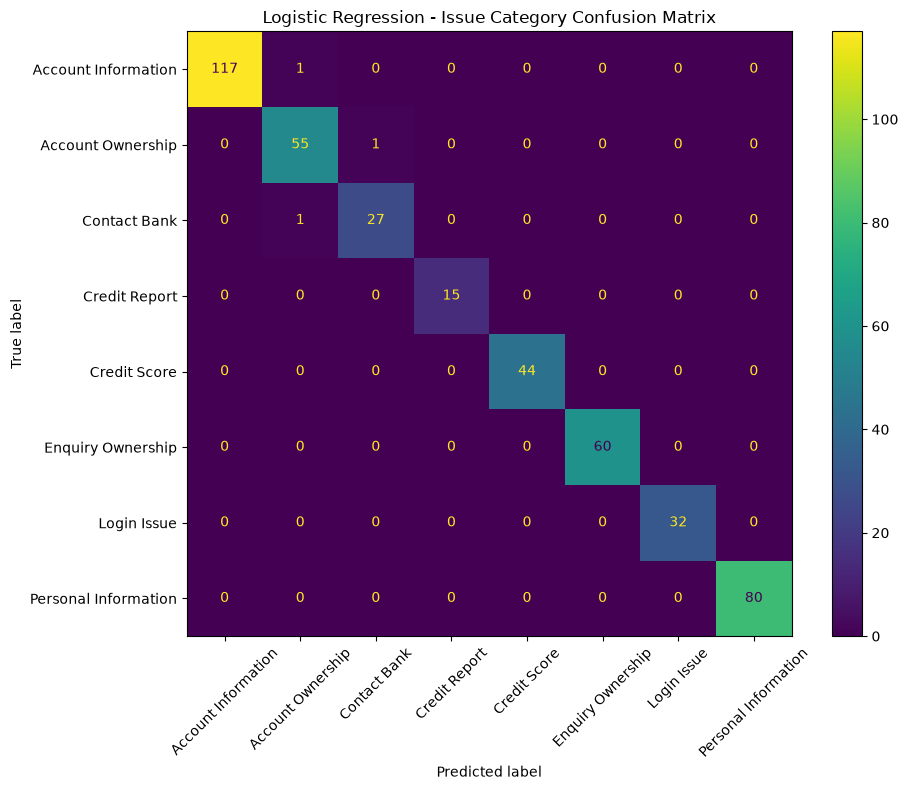

In [143]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_encoded,
    y_pred_lr
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("Logistic Regression - Issue Category Confusion Matrix")
plt.tight_layout()
plt.show()

In [145]:
import joblib

model_package = {
    "model": logistic_model,
    "word_tfidf": word_tfidf,
    "char_tfidf": char_tfidf,
    "label_encoder": label_encoder
}

joblib.dump(
    model_package,
    "credit_complaint_logistic_regression_model.joblib"
)

print("Model package saved successfully.")

Model package saved successfully.


In [147]:
def predict_issue_category(complaint_text):

    # Clean text
    cleaned_text = clean_text(complaint_text)

    # TF-IDF transformation
    word_features = word_tfidf.transform([cleaned_text])
    char_features = char_tfidf.transform([cleaned_text])

    # Combine features
    features = hstack([
        word_features,
        char_features
    ])

    # Prediction
    prediction = logistic_model.predict(features)

    # Convert prediction to category
    category = label_encoder.inverse_transform(prediction)[0]

    # Confidence
    probabilities = logistic_model.predict_proba(features)[0]
    confidence = probabilities.max()

    return category, confidence

In [151]:
test_voc = "I have never opened this loan account but it is showing on my credit report."

category, confidence = predict_issue_category(test_voc)

print("VOC:", test_voc)
print("Predicted Issue Category:", category)
print("Confidence:", round(confidence, 4))

VOC: I have never opened this loan account but it is showing on my credit report.
Predicted Issue Category: Account Ownership
Confidence: 0.8052


In [153]:
all_clean_text = ml_df["Clean_Complaint_Text"]

all_word = word_tfidf.transform(all_clean_text)
all_char = char_tfidf.transform(all_clean_text)

all_features = hstack([
    all_word,
    all_char
])

In [158]:
all_predictions = logistic_model.predict(all_features)

all_categories = label_encoder.inverse_transform(
    all_predictions
)

all_probabilities = logistic_model.predict_proba(all_features)

all_confidence = all_probabilities.max(axis=1)

In [162]:
prediction_file = ml_df.copy()

prediction_file["Predicted_Issue_Category"] = all_categories
prediction_file["Prediction_Confidence"] = all_confidence

display(
    prediction_file[
        [
            "Complaint_Text",
            "Issue_Category",
            "Predicted_Issue_Category",
            "Prediction_Confidence"
        ]
    ].head(10)
)

,Complaint_Text,Issue_Category,Predicted_Issue_Category,Prediction_Confidence
0,"My personal loan was closed three months ago, ...",Account Information,Account Information,0.899744
1,Mera loan close ho gaya hai lekin CIBIL report...,Account Information,Account Information,0.857324
2,This credit card does not belong to me. Fraudl...,Account Ownership,Account Ownership,0.875083
3,माझ्या अहवालात DPD चुकीचा दाखवत आहे. मी सर्व E...,Account Information,Account Information,0.724305
4,My credit score has dropped by almost 80 point...,Credit Score,Credit Score,0.952178
5,I am writing to formally log a critical discre...,Personal Information,Personal Information,0.661212
6,maine kabhi bhi ye credit institutionse koi bh...,Enquiry Ownership,Enquiry Ownership,0.696543
7,I am Krishna Kishore as check the latest repor...,Personal Information,Personal Information,0.744634
8,"Dear Nodal Officer, As check my report I am se...",Account Information,Account Information,0.813325
9,I have fully paid my personal but it is showin...,Account Information,Account Information,0.891929


In [164]:
prediction_file = df.copy()

prediction_file["Predicted_Issue_Category"] = all_categories
prediction_file["Prediction_Confidence"] = all_confidence

display(
    prediction_file[
        [
            "Complaint_ID",
            "Complaint_Text",
            "Issue_Category",
            "Predicted_Issue_Category",
            "Prediction_Confidence"
        ]
    ].head(10)
)

,Complaint_ID,Complaint_Text,Issue_Category,Predicted_Issue_Category,Prediction_Confidence
0,VOC0001,"My personal loan was closed three months ago, ...",Account Information,Account Information,0.899744
1,VOC0002,Mera loan close ho gaya hai lekin CIBIL report...,Account Information,Account Information,0.857324
2,VOC0003,This credit card does not belong to me. Fraudl...,Account Ownership,Account Ownership,0.875083
3,VOC0004,माझ्या अहवालात DPD चुकीचा दाखवत आहे. मी सर्व E...,Account Information,Account Information,0.724305
4,VOC0005,My credit score has dropped by almost 80 point...,Credit Score,Credit Score,0.952178
5,VOC0006,I am writing to formally log a critical discre...,Personal Information,Personal Information,0.661212
6,VOC0007,maine kabhi bhi ye credit institutionse koi bh...,Enquiry Ownership,Enquiry Ownership,0.696543
7,VOC0008,I am Krishna Kishore as check the latest repor...,Personal Information,Personal Information,0.744634
8,VOC0009,"Dear Nodal Officer, As check my report I am se...",Account Information,Account Information,0.813325
9,VOC0010,I have fully paid my personal but it is showin...,Account Information,Account Information,0.891929


In [168]:
prediction_file.to_excel(
    "Credit_Complaint_Final_Predictions.xlsx",
    index=False
)

print("Final prediction file created successfully.")

Final prediction file created successfully.


In [170]:
import joblib

model_package = {
    "model": logistic_model,
    "word_tfidf": word_tfidf,
    "char_tfidf": char_tfidf,
    "label_encoder": label_encoder
}

joblib.dump(
    model_package,
    "credit_complaint_logistic_regression_model.joblib"
)

print("Model package saved successfully.")


Model package saved successfully.


In [172]:

from sklearn.svm import LinearSVC

# Create SVM model
svm_model = LinearSVC(
    C=2.0,
    class_weight="balanced"
)

# Train SVM
svm_model.fit(
    X_train_tfidf,
    y_train_encoded
)

print("SVM training completed.")

SVM training completed.


In [174]:
# ============================================================
# SVM PREDICTIONS
# ============================================================

y_pred_svm = svm_model.predict(
    X_test_tfidf
)

print(
    "SVM Predictions Generated:",
    len(y_pred_svm)
)

SVM Predictions Generated: 433


In [179]:
# ============================================================
# SVM EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

accuracy_svm = accuracy_score(
    y_test_encoded,
    y_pred_svm
)

precision_svm, recall_svm, f1_svm, _ = (
    precision_recall_fscore_support(
        y_test_encoded,
        y_pred_svm,
        average="macro",
        zero_division=0
    )
)

print("SVM Results")
print("=" * 50)

print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"Macro F1 : {f1_svm:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred_svm,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

SVM Results
Accuracy : 0.9954
Precision: 0.9933
Recall   : 0.9933
Macro F1 : 0.9933

Classification Report:
                      precision    recall  f1-score   support

 Account Information       1.00      1.00      1.00       118
   Account Ownership       0.98      0.98      0.98        56
        Contact Bank       0.96      0.96      0.96        28
       Credit Report       1.00      1.00      1.00        15
        Credit Score       1.00      1.00      1.00        44
   Enquiry Ownership       1.00      1.00      1.00        60
         Login Issue       1.00      1.00      1.00        32
Personal Information       1.00      1.00      1.00        80

            accuracy                           1.00       433
           macro avg       0.99      0.99      0.99       433
        weighted avg       1.00      1.00      1.00       433



In [181]:
# ============================================================
# MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Macro F1"
    ],

    "Logistic Regression": [
        accuracy_lr,
        precision_lr,
        recall_lr,
        f1_lr
    ],

    "Linear SVM": [
        accuracy_svm,
        precision_svm,
        recall_svm,
        f1_svm
    ]
})

display(comparison)

,Metric,Logistic Regression,Linear SVM
0,Accuracy,0.993072,0.995381
1,Precision,0.991150,0.993304
2,Recall,0.992244,0.993304
3,Macro F1,0.991685,0.993304
